In [ ]:
##Imports and setup
import random
import time
import math
import gc
import tracemalloc
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.setrecursionlimit(10000)

os.makedirs("figures", exist_ok=True)

sizes = list(range(100, 1001, 100))
trials = 10

input_types = [
    "random",
    "sorted",
    "reverse_sorted",
    "nearly_sorted",
    "duplicate_heavy"
]

In [ ]:
##Input Array Generator
def generate_array(n, input_type):
    if input_type == "random":
        return [random.randint(1, 10000) for _ in range(n)]

    elif input_type == "sorted":
        return list(range(1, n + 1))

    elif input_type == "reverse_sorted":
        return list(range(n, 0, -1))

    elif input_type == "nearly_sorted":
        arr = list(range(1, n + 1))
        swaps = max(1, n // 10)

        for _ in range(swaps):
            i = random.randint(0, n - 1)
            j = random.randint(0, n - 1)
            arr[i], arr[j] = arr[j], arr[i]

        return arr

    elif input_type == "duplicate_heavy":
        return [random.randint(1, 10) for _ in range(n)]

    else:
        raise ValueError("Invalid input type")

In [ ]:
##Heap sort with metrics collection
def heap_sort(arr):
    metrics = {
        "comparisons": 0,
        "swaps": 0,
        "recursive_calls": 0,
        "max_depth": 0
    }

    n = len(arr)

    def heapify(arr, heap_size, root_index, depth):
        metrics["recursive_calls"] += 1
        metrics["max_depth"] = max(metrics["max_depth"], depth)

        largest = root_index
        left = 2 * root_index + 1
        right = 2 * root_index + 2

        if left < heap_size:
            metrics["comparisons"] += 1
            if arr[left] > arr[largest]:
                largest = left

        if right < heap_size:
            metrics["comparisons"] += 1
            if arr[right] > arr[largest]:
                largest = right

        if largest != root_index:
            arr[root_index], arr[largest] = arr[largest], arr[root_index]
            metrics["swaps"] += 1
            heapify(arr, heap_size, largest, depth + 1)

    for i in range(n // 2 - 1, -1, -1):
        heapify(arr, n, i, 1)

    for i in range(n - 1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        metrics["swaps"] += 1
        heapify(arr, i, 0, 1)

    return arr, metrics

In [ ]:
##Merge sort with metrics collection
def merge_sort(arr):
    metrics = {
        "comparisons": 0,
        "swaps": 0,
        "recursive_calls": 0,
        "max_depth": 0
    }

    def merge_sort_recursive(arr, depth):
        metrics["recursive_calls"] += 1
        metrics["max_depth"] = max(metrics["max_depth"], depth)

        if len(arr) <= 1:
            return arr

        mid = len(arr) // 2
        left = merge_sort_recursive(arr[:mid], depth + 1)
        right = merge_sort_recursive(arr[mid:], depth + 1)

        return merge(left, right)

    def merge(left, right):
        result = []
        i = 0
        j = 0

        while i < len(left) and j < len(right):
            metrics["comparisons"] += 1

            if left[i] <= right[j]:
                result.append(left[i])
                i += 1
            else:
                result.append(right[j])
                j += 1

            metrics["swaps"] += 1

        while i < len(left):
            result.append(left[i])
            i += 1
            metrics["swaps"] += 1

        while j < len(right):
            result.append(right[j])
            j += 1
            metrics["swaps"] += 1

        return result

    sorted_arr = merge_sort_recursive(arr, 1)
    return sorted_arr, metrics

In [ ]:
##Quick sort with metrics collection
def quick_sort(arr):
    metrics = {
        "comparisons": 0,
        "swaps": 0,
        "recursive_calls": 0,
        "max_depth": 0
    }

    def partition(arr, low, high):
        pivot = arr[high]
        i = low - 1

        for j in range(low, high):
            metrics["comparisons"] += 1

            if arr[j] <= pivot:
                i += 1

                if i != j:
                    arr[i], arr[j] = arr[j], arr[i]
                    metrics["swaps"] += 1

        if i + 1 != high:
            arr[i + 1], arr[high] = arr[high], arr[i + 1]
            metrics["swaps"] += 1

        return i + 1

    def quick_sort_recursive(arr, low, high, depth):
        metrics["recursive_calls"] += 1
        metrics["max_depth"] = max(metrics["max_depth"], depth)

        if low < high:
            pivot_index = partition(arr, low, high)

            quick_sort_recursive(arr, low, pivot_index - 1, depth + 1)
            quick_sort_recursive(arr, pivot_index + 1, high, depth + 1)

    quick_sort_recursive(arr, 0, len(arr) - 1, 1)

    return arr, metrics

In [ ]:
##Measurement function for sorting algorithms
def measure_algorithm(sort_function, arr):
    gc.collect()
    gc.disable()

    tracemalloc.start()

    start_time = time.perf_counter()
    sorted_arr, metrics = sort_function(arr.copy())
    end_time = time.perf_counter()

    current_memory, peak_memory = tracemalloc.get_traced_memory()

    tracemalloc.stop()
    gc.enable()

    time_taken = end_time - start_time

    return sorted_arr, metrics, time_taken, peak_memory

In [ ]:
##Run experiments and collect results
algorithms = {
    "Heap Sort": heap_sort,
    "Merge Sort": merge_sort,
    "Quick Sort": quick_sort
}

raw_results = []

for input_type in input_types:
    print(f"\nInput Type: {input_type}")

    for n in sizes:
        print(f"Running n = {n}")

        for trial in range(1, trials + 1):
            original_array = generate_array(n, input_type)

            trial_results = {}

            for algorithm_name, algorithm_function in algorithms.items():
                sorted_arr, metrics, time_taken, peak_memory = measure_algorithm(
                    algorithm_function,
                    original_array
                )

                trial_results[algorithm_name] = sorted_arr

                constant_factor = time_taken / (n * math.log2(n))

                raw_results.append({
                    "Input Type": input_type,
                    "n": n,
                    "Trial": trial,
                    "Algorithm": algorithm_name,
                    "Time": time_taken,
                    "Comparisons": metrics["comparisons"],
                    "Swaps/Data Movements": metrics["swaps"],
                    "Recursive Calls": metrics["recursive_calls"],
                    "Max Recursion Depth": metrics["max_depth"],
                    "Peak Memory Bytes": peak_memory,
                    "Constant c": constant_factor
                })

            if not (
                trial_results["Heap Sort"] ==
                trial_results["Merge Sort"] ==
                trial_results["Quick Sort"]
            ):
                print(f"Mismatch found for {input_type}, n = {n}, trial = {trial}")

print("\nExperiment completed successfully.")


Input Type: random
Running n = 100
Running n = 200
Running n = 300
Running n = 400
Running n = 500
Running n = 600
Running n = 700
Running n = 800
Running n = 900
Running n = 1000

Input Type: sorted
Running n = 100
Running n = 200
Running n = 300
Running n = 400
Running n = 500
Running n = 600
Running n = 700
Running n = 800
Running n = 900
Running n = 1000

Input Type: reverse_sorted
Running n = 100
Running n = 200
Running n = 300
Running n = 400
Running n = 500
Running n = 600
Running n = 700
Running n = 800
Running n = 900
Running n = 1000

Input Type: nearly_sorted
Running n = 100
Running n = 200
Running n = 300
Running n = 400
Running n = 500
Running n = 600
Running n = 700
Running n = 800
Running n = 900
Running n = 1000

Input Type: duplicate_heavy
Running n = 100
Running n = 200
Running n = 300
Running n = 400
Running n = 500
Running n = 600
Running n = 700
Running n = 800
Running n = 900
Running n = 1000

Experiment completed successfully.


In [ ]:
##Create raw results csv
raw_df = pd.DataFrame(raw_results)

raw_df.to_csv("raw_results.csv", index=False)

raw_df.head()

,Input Type,n,Trial,Algorithm,Time,Comparisons,Swaps/Data Movements,Recursive Calls,Max Recursion Depth,Peak Memory Bytes,Constant c
0,random,100,1,Heap Sort,0.002859,1038,580,630,7,1376,0.000004
1,random,100,1,Merge Sort,0.001323,545,672,199,8,3736,0.000002
2,random,100,1,Quick Sort,0.000904,598,226,131,12,1544,0.000001
3,random,100,2,Heap Sort,0.003421,1021,579,629,7,1352,0.000005
4,random,100,2,Merge Sort,0.003155,549,672,199,8,3744,0.000005


In [ ]:
##Create final summary table
summary_df = raw_df.groupby(
    ["Input Type", "n", "Algorithm"],
    as_index=False
).agg(
    Avg_Time=("Time", "mean"),
    Min_Time=("Time", "min"),
    Max_Time=("Time", "max"),
    Avg_Comparisons=("Comparisons", "mean"),
    Avg_Swaps_Data_Movements=("Swaps/Data Movements", "mean"),
    Avg_Recursive_Calls=("Recursive Calls", "mean"),
    Avg_Max_Recursion_Depth=("Max Recursion Depth", "mean"),
    Avg_Peak_Memory_Bytes=("Peak Memory Bytes", "mean"),
    Avg_Constant_c=("Constant c", "mean")
)

summary_df.to_csv("results.csv", index=False)

summary_df

,Input Type,n,Algorithm,Avg_Time,Min_Time,Max_Time,Avg_Comparisons,Avg_Swaps_Data_Movements,Avg_Recursive_Calls,Avg_Max_Recursion_Depth,Avg_Peak_Memory_Bytes,Avg_Constant_c
0,duplicate_heavy,100,Heap Sort,0.003232,0.001755,0.007166,993.1,537.6,587.6,7.0,16399.2,0.000005
1,duplicate_heavy,100,Merge Sort,0.001855,0.001594,0.002547,535.3,672.0,199.0,8.0,4152.0,0.000003
2,duplicate_heavy,100,Quick Sort,0.001368,0.000879,0.002662,861.4,166.3,181.0,19.8,1544.0,0.000002
3,duplicate_heavy,200,Heap Sort,0.006860,0.005161,0.009770,2345.4,1252.1,1352.1,8.0,17229.7,0.000004
4,duplicate_heavy,200,Merge Sort,0.004712,0.003844,0.006165,1251.3,1544.0,399.0,9.0,6736.0,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...
145,sorted,900,Merge Sort,0.027181,0.024437,0.029865,4304.0,8876.0,1799.0,11.0,24304.0,0.000003
146,sorted,900,Quick Sort,2.321526,2.218694,2.631608,404550.0,0.0,1799.0,900.0,114368.7,0.000263
147,sorted,1000,Heap Sort,0.063948,0.059171,0.079135,17583.0,9708.0,10208.0,10.0,23700.0,0.000006
148,sorted,1000,Merge Sort,0.033576,0.028703,0.046714,4932.0,9976.0,1999.0,11.0,27152.0,0.000003


In [ ]:
##Graph function
def plot_metric(metric_column, y_label, file_name):
    for input_type in input_types:
        plt.figure(figsize=(10, 6))

        data = summary_df[summary_df["Input Type"] == input_type]

        for algorithm in algorithms.keys():
            algorithm_data = data[data["Algorithm"] == algorithm]

            plt.plot(
                algorithm_data["n"],
                algorithm_data[metric_column],
                marker="o",
                label=algorithm
            )

        plt.xlabel("Input Size (n)")
        plt.ylabel(y_label)
        plt.title(f"{y_label} vs Input Size ({input_type})")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        save_path = f"figures/{file_name}_{input_type}.png"
        plt.savefig(save_path)
        plt.show()

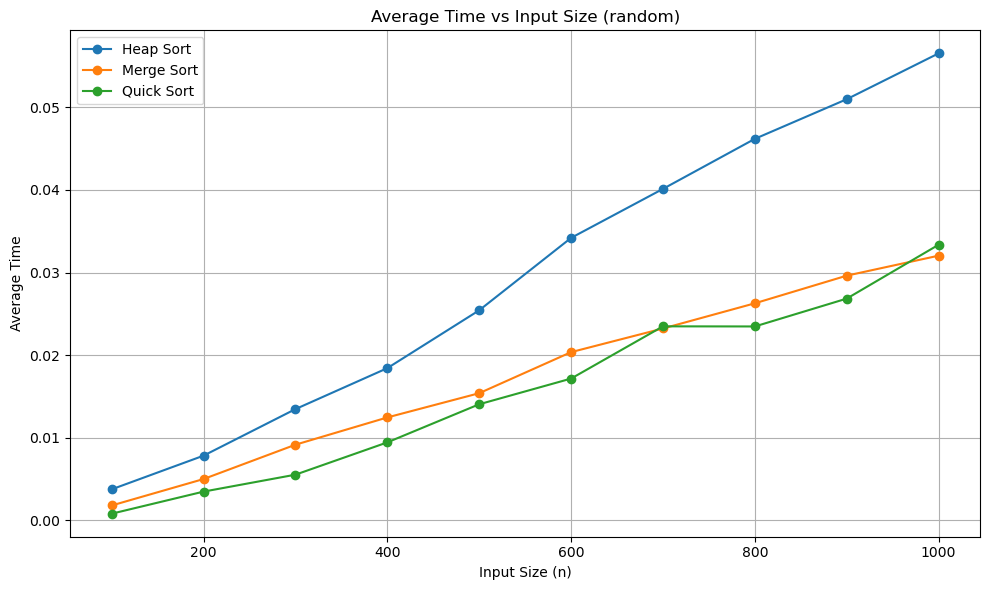

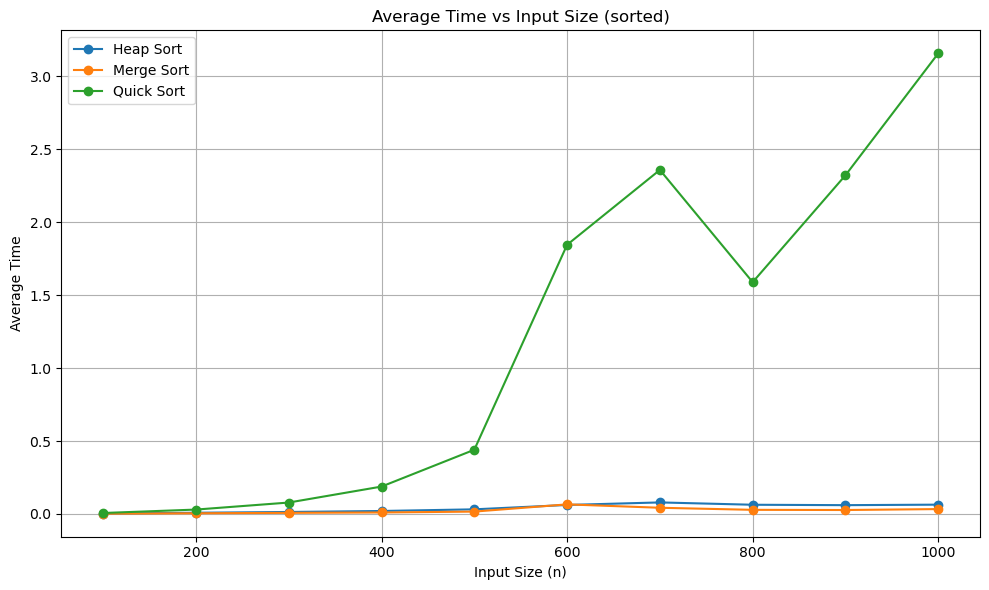

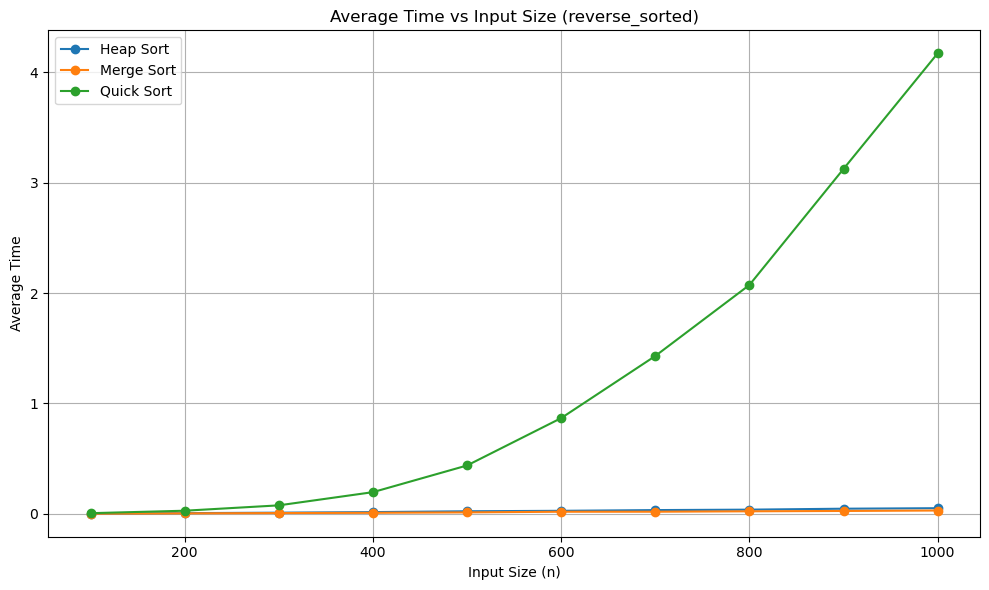

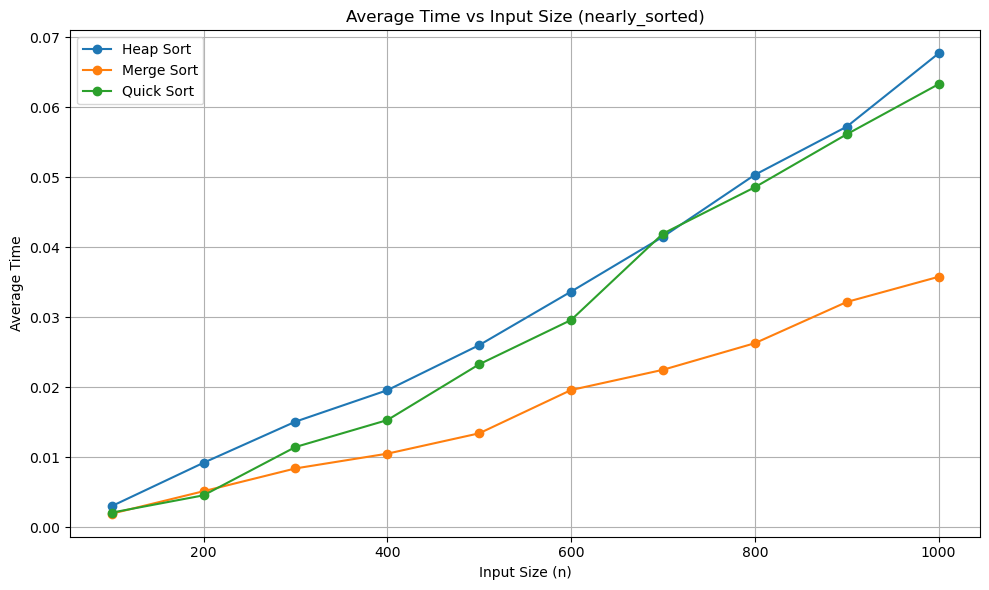

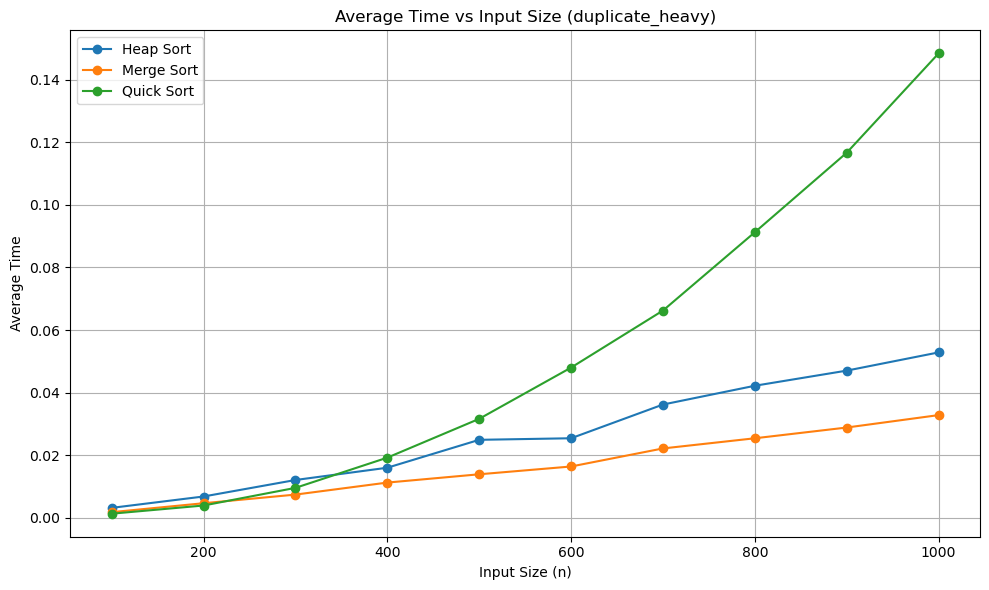

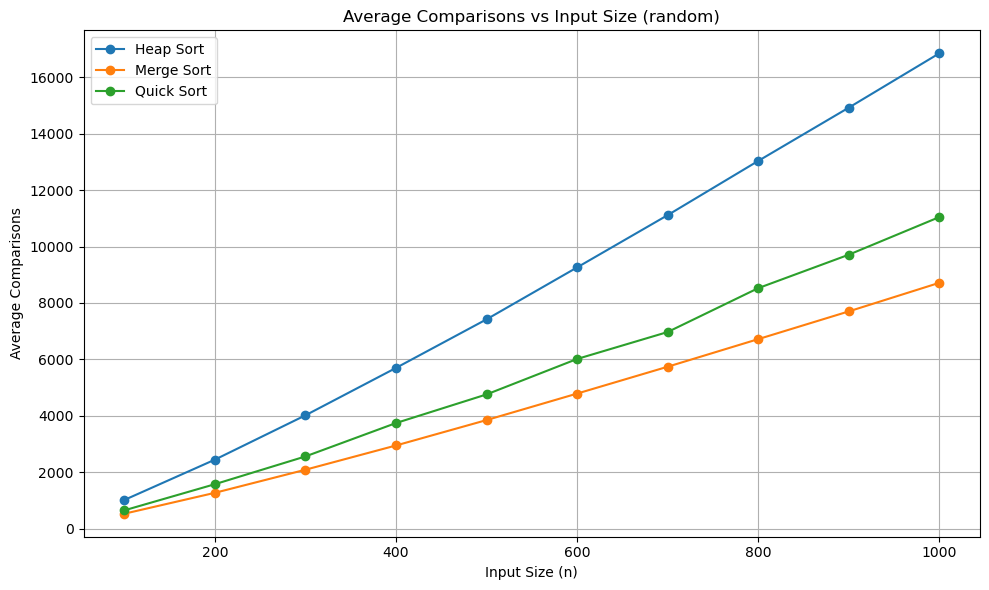

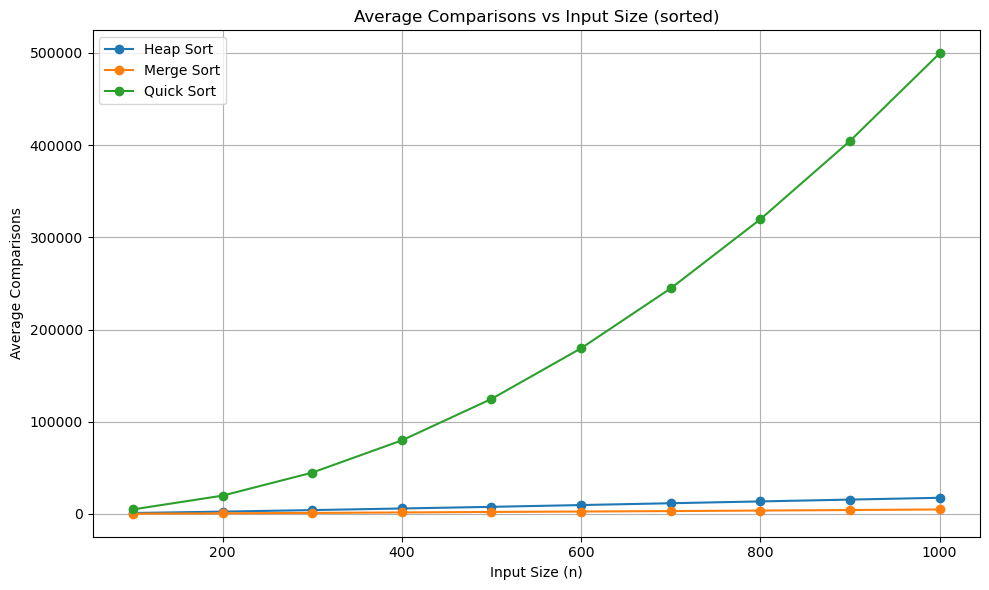

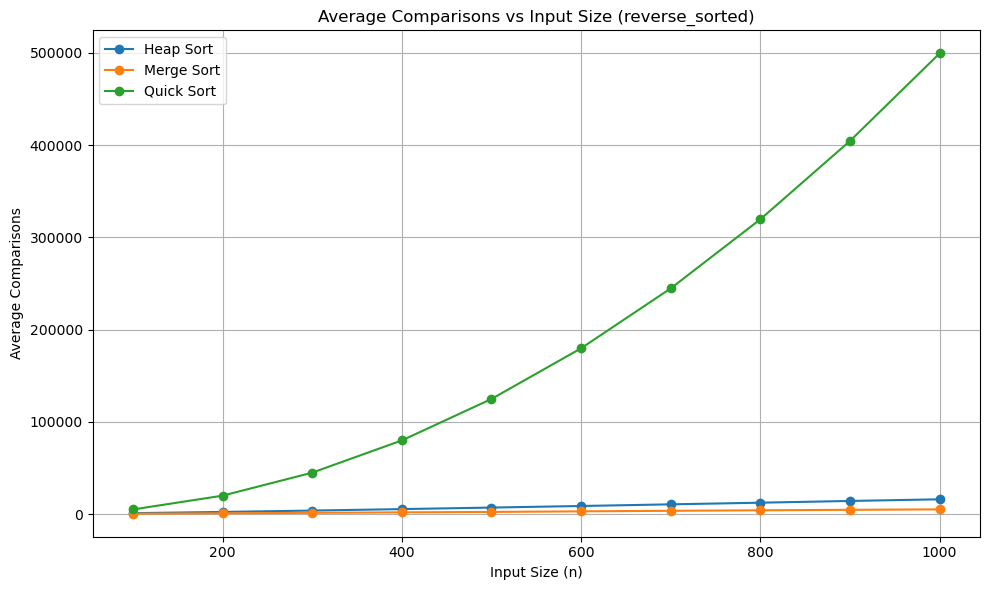

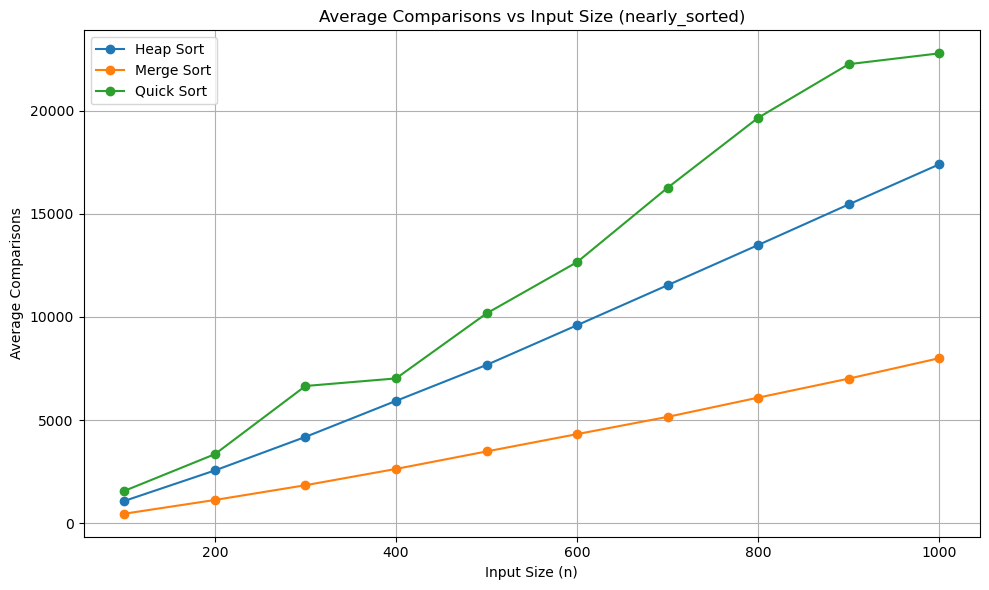

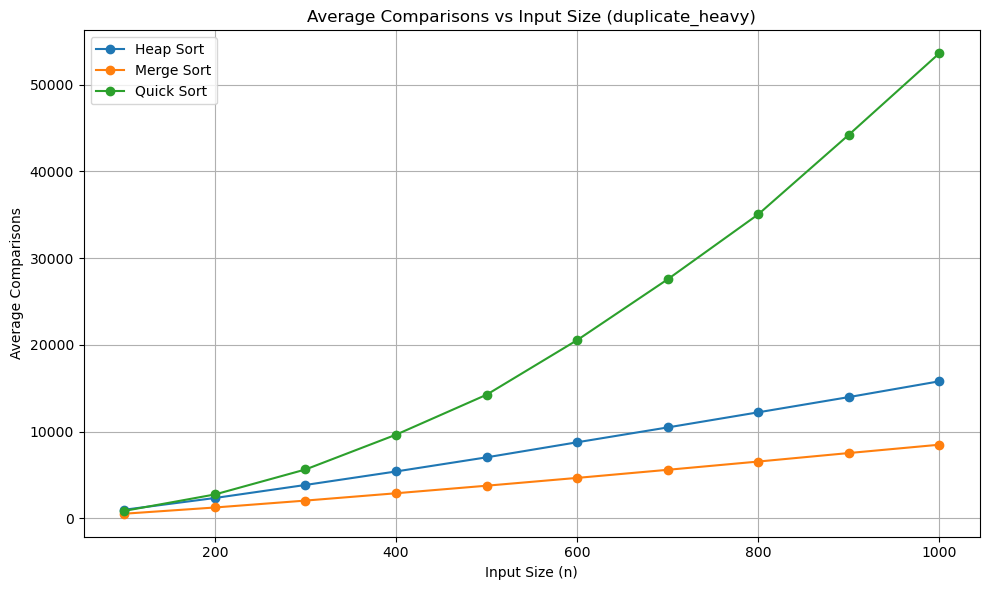

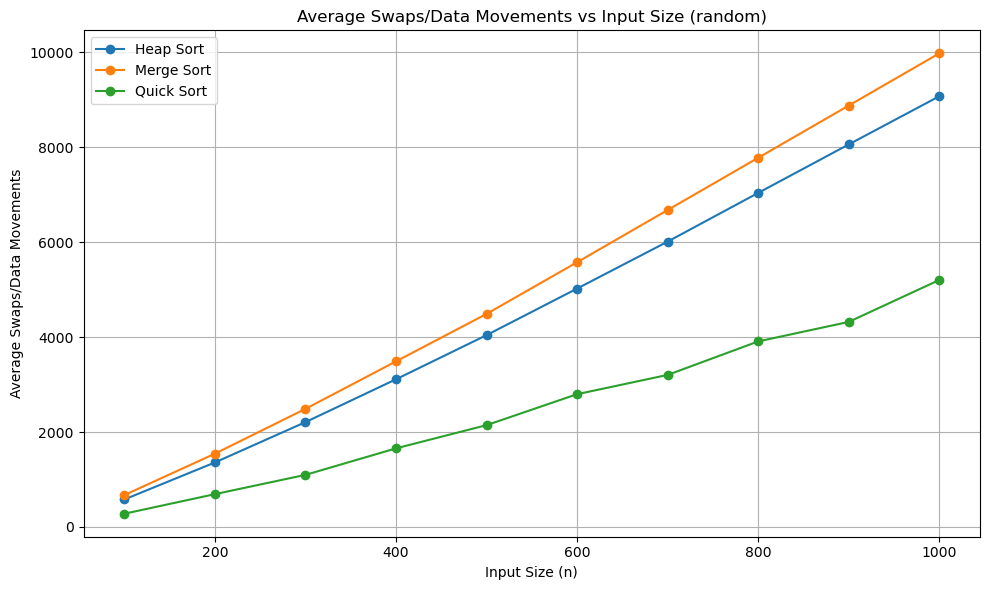

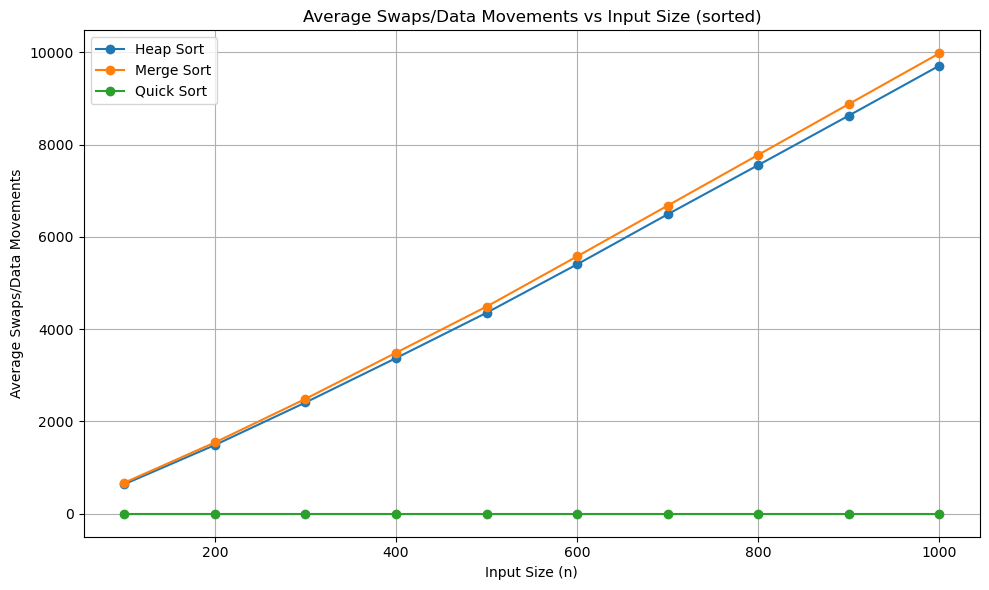

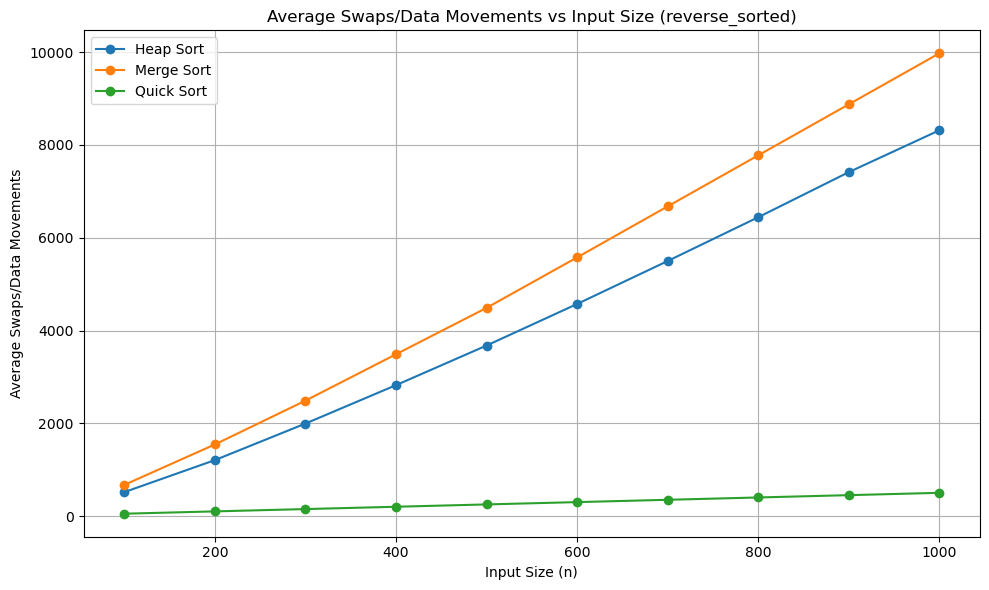

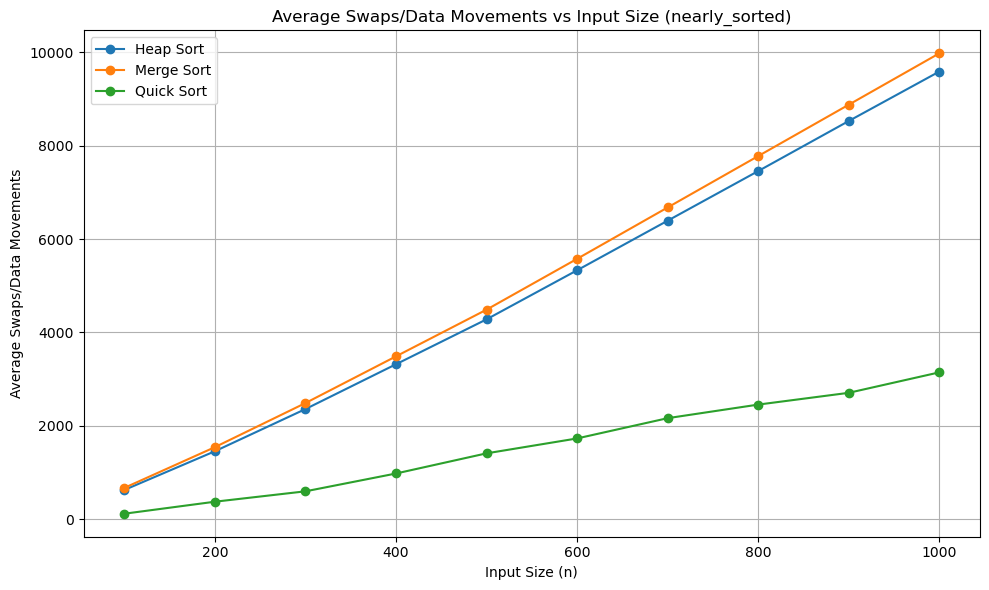

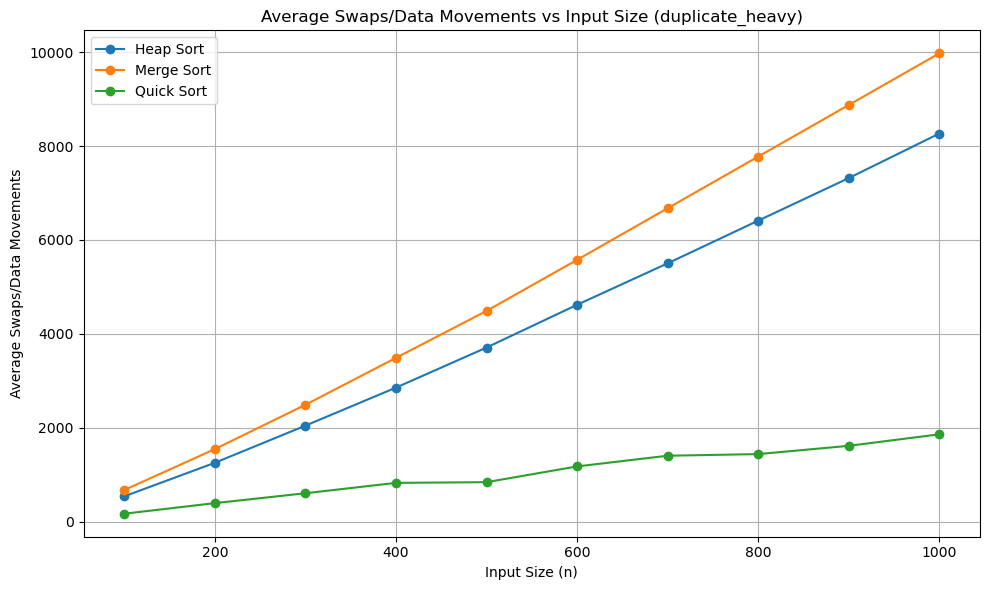

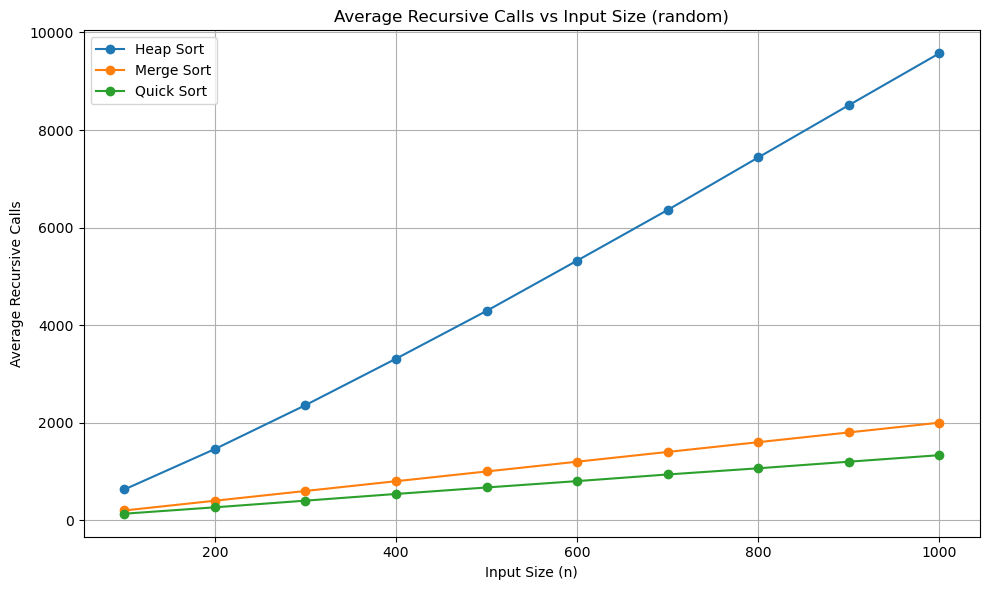

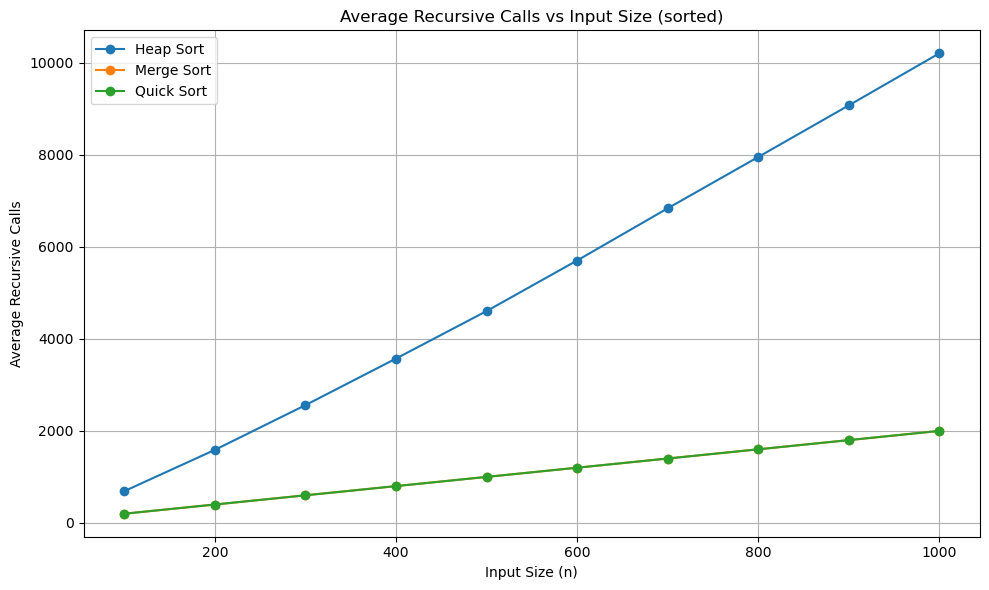

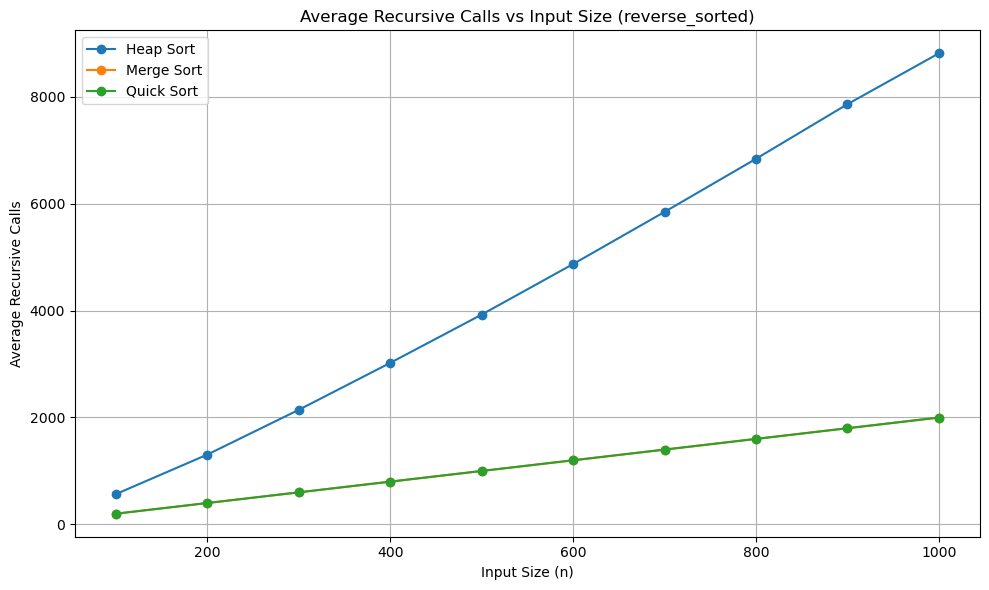

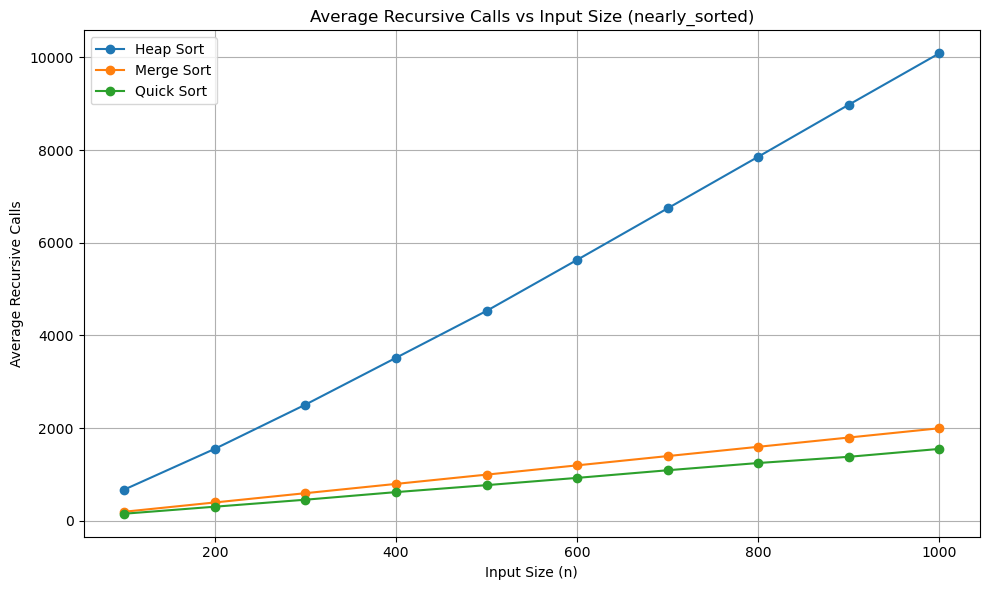

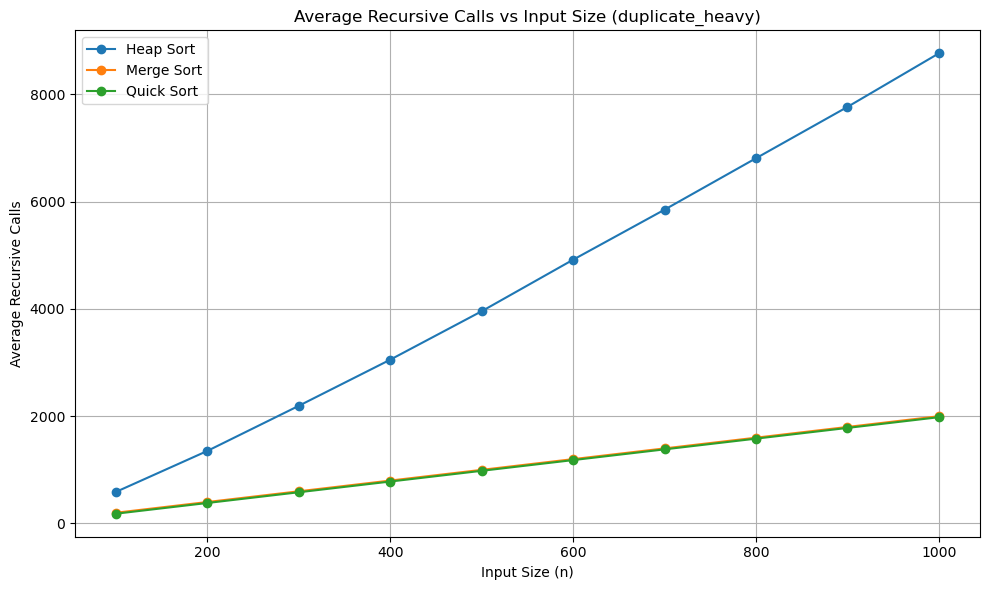

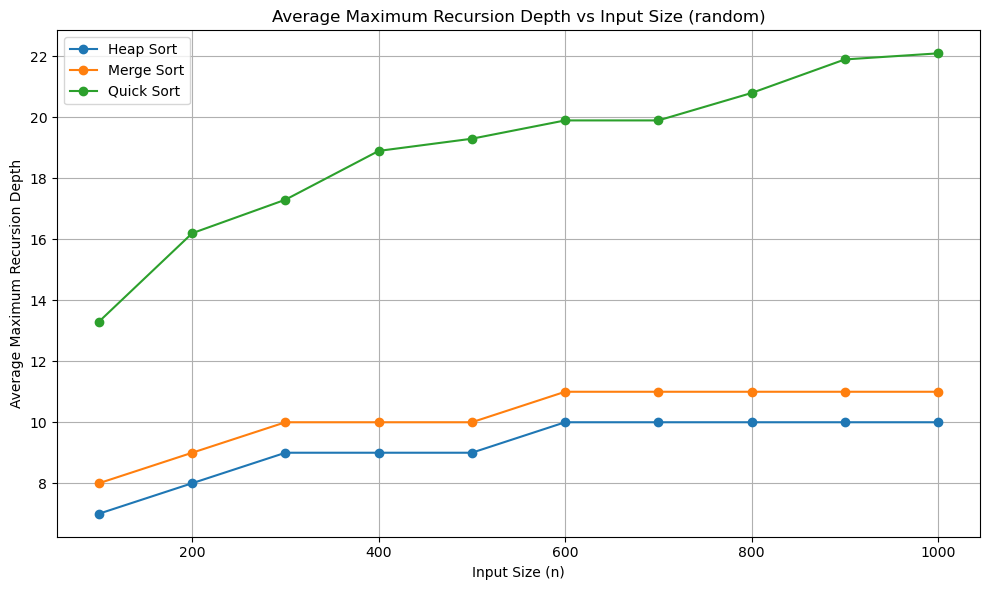

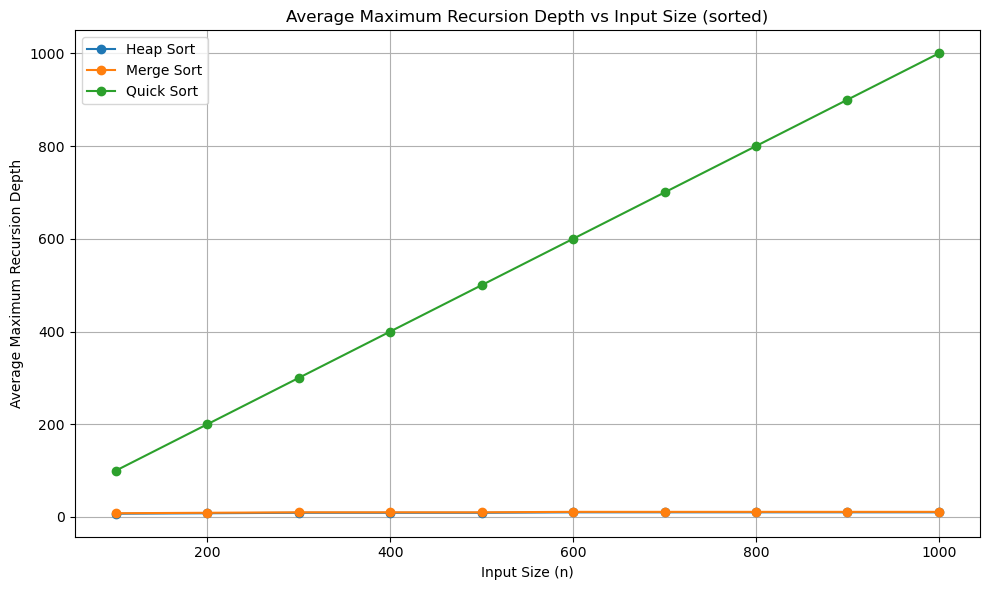

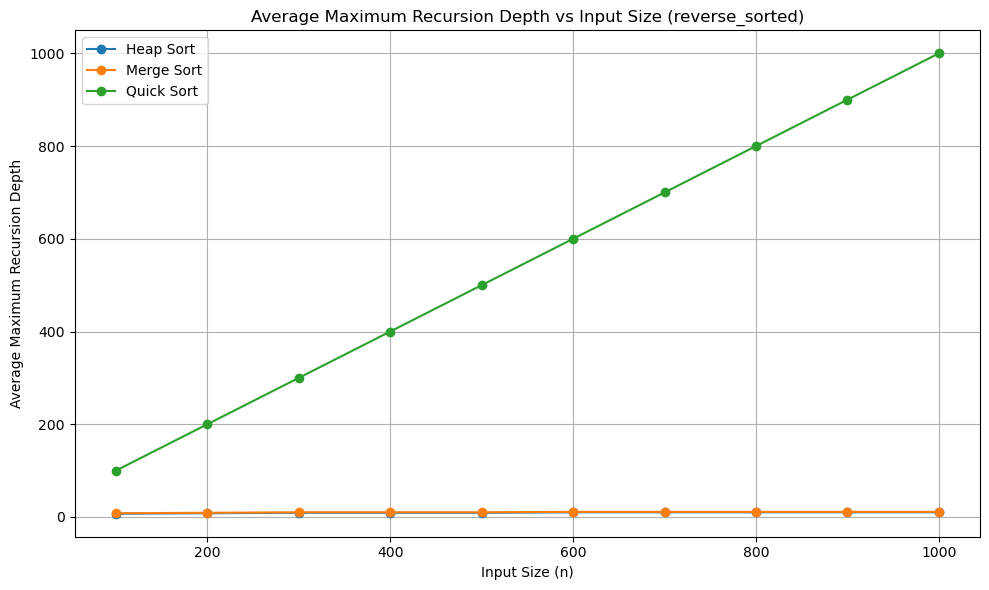

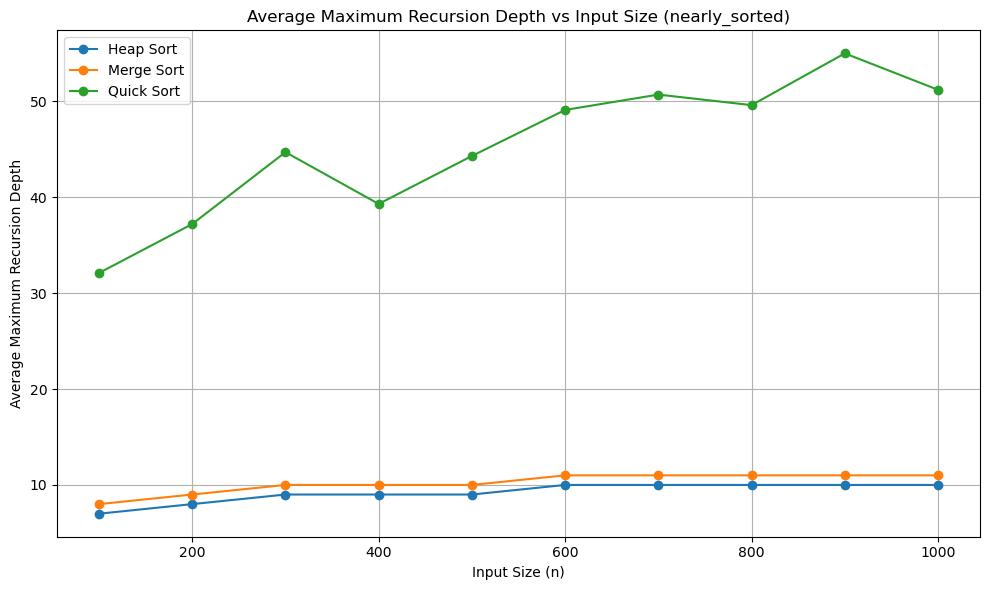

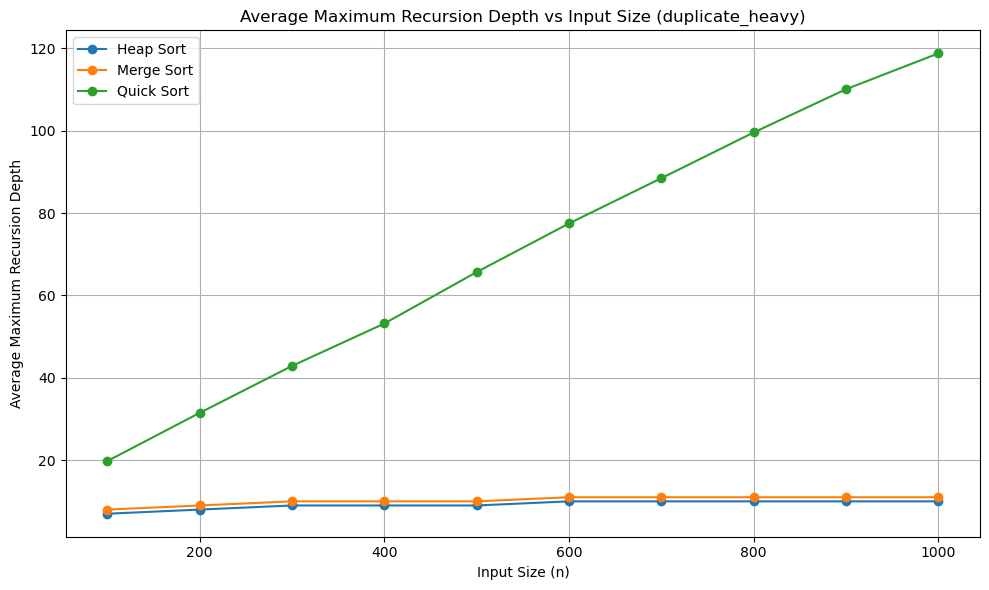

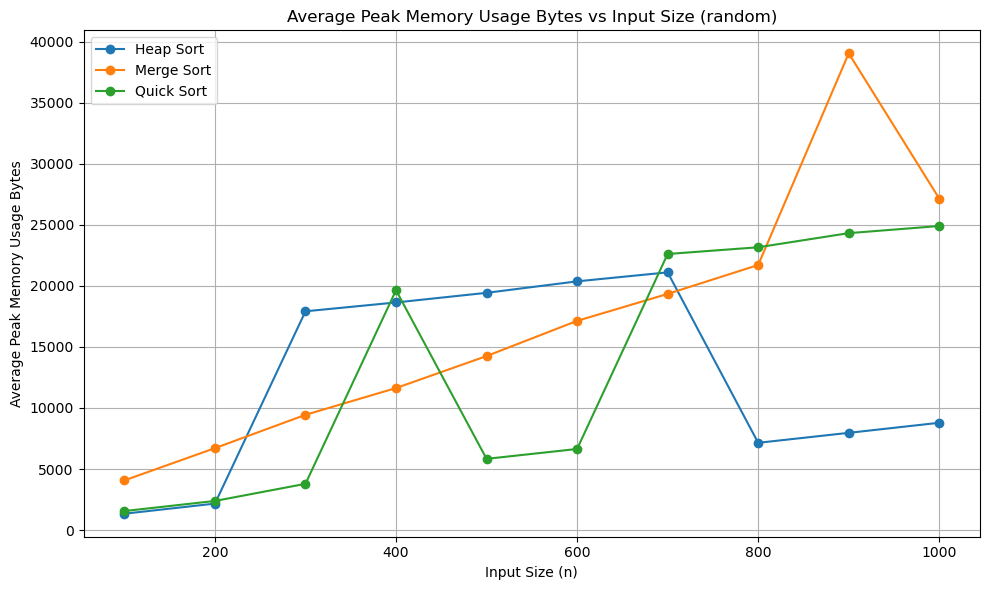

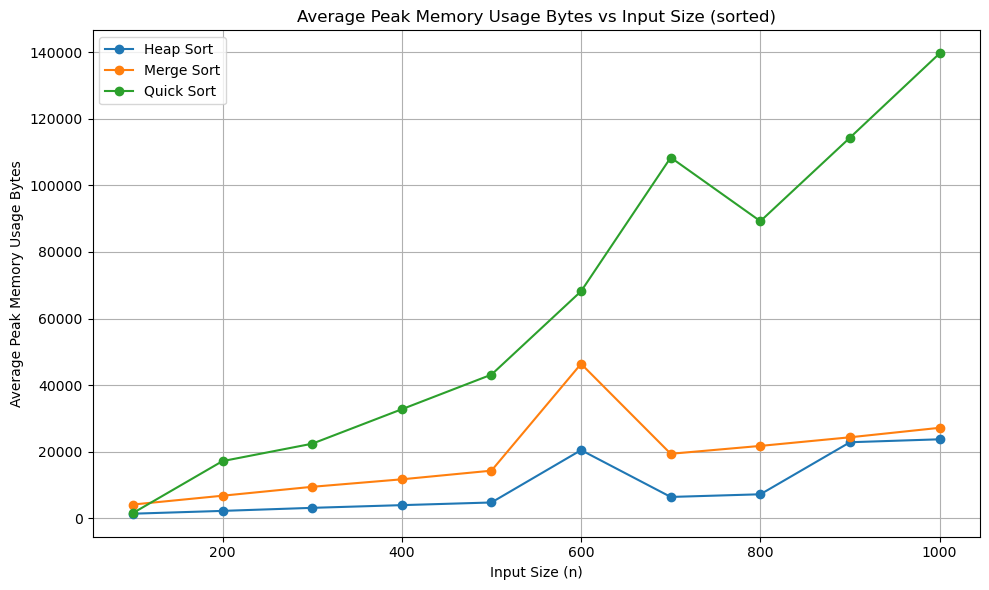

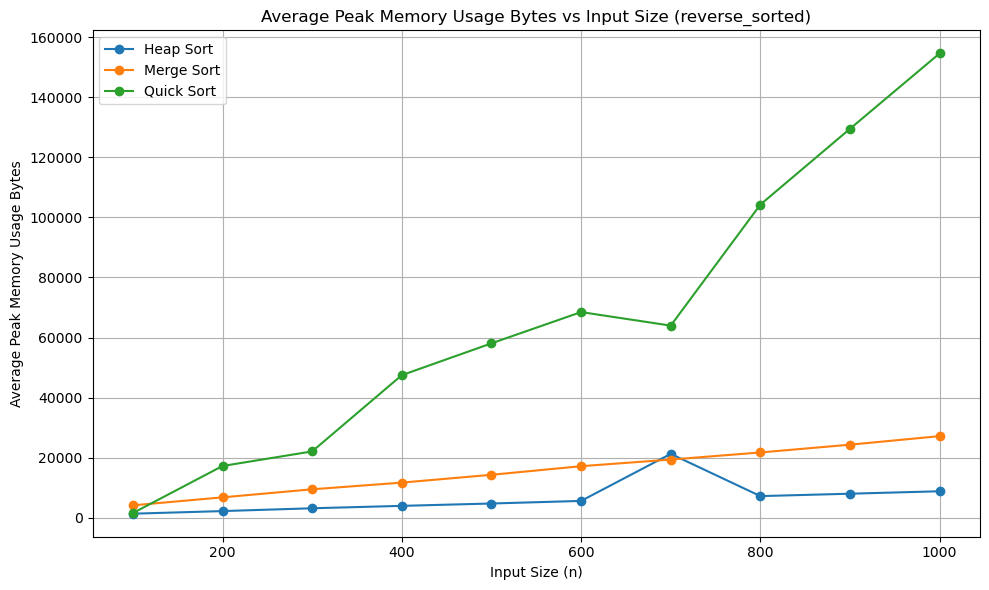

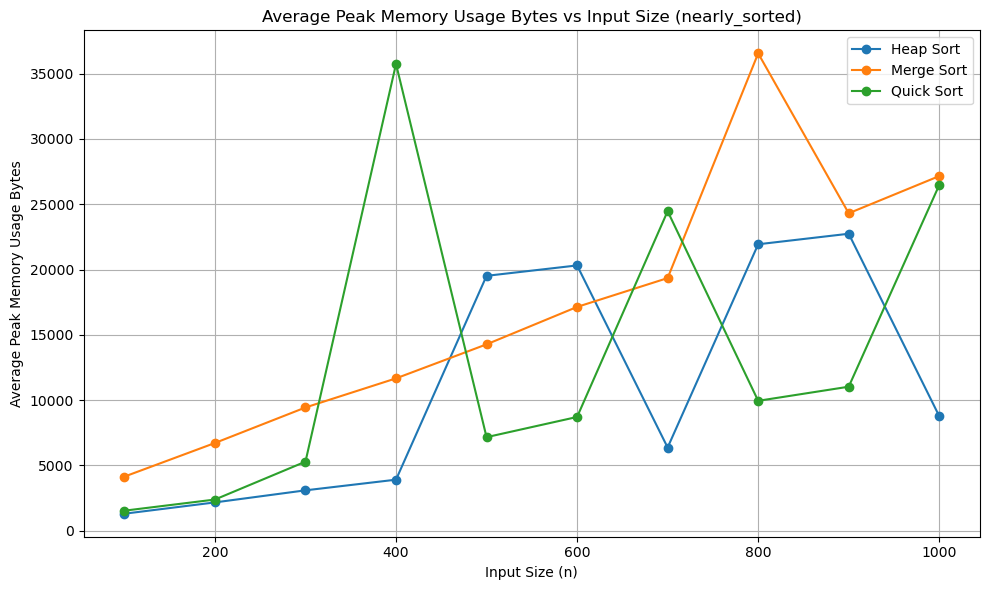

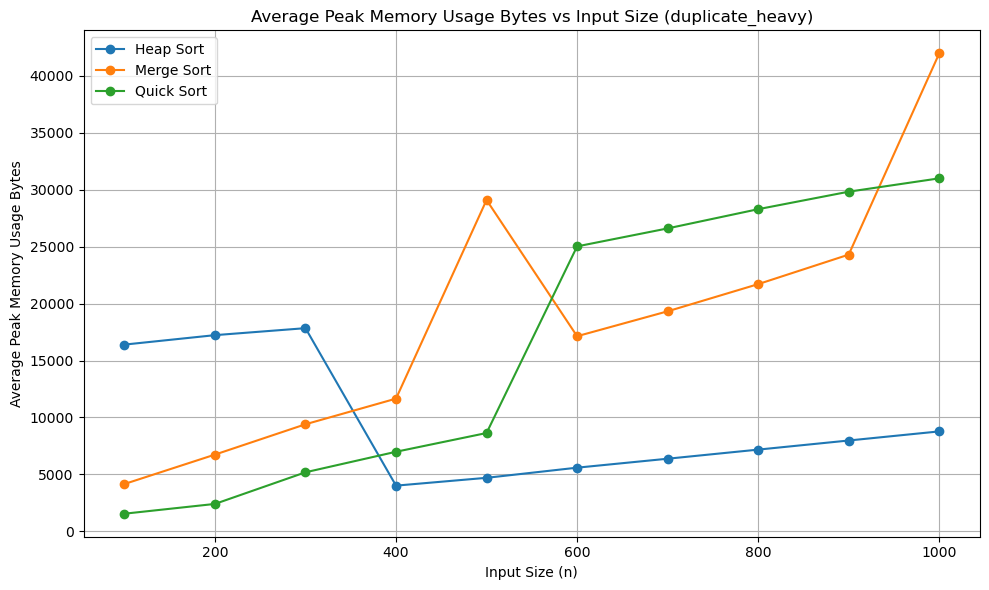

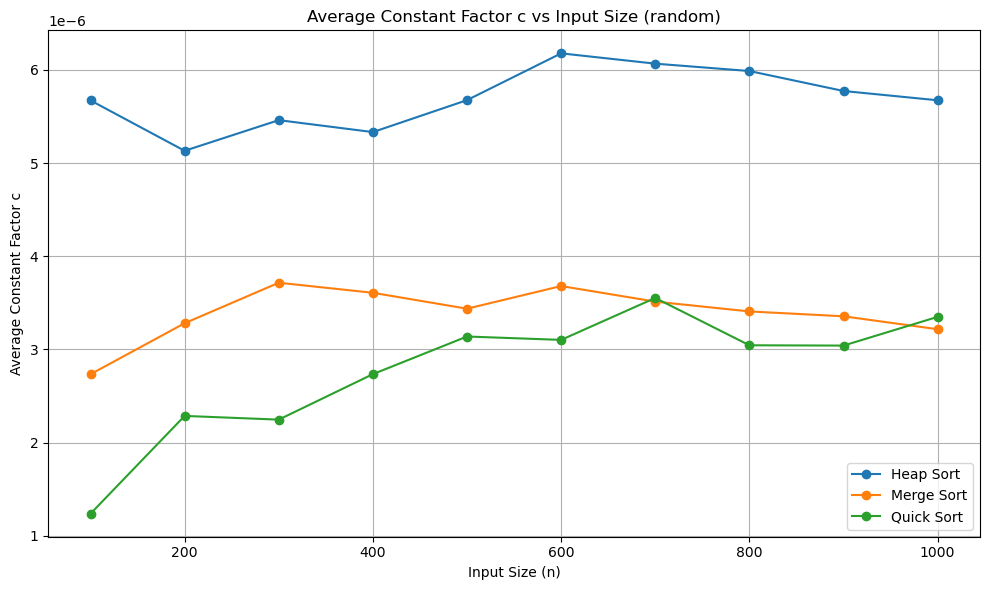

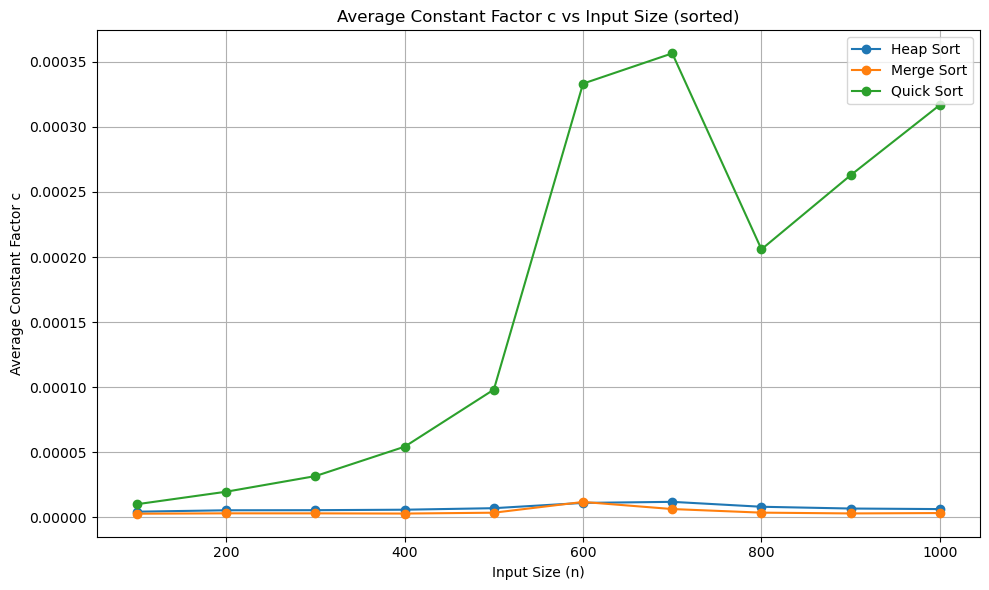

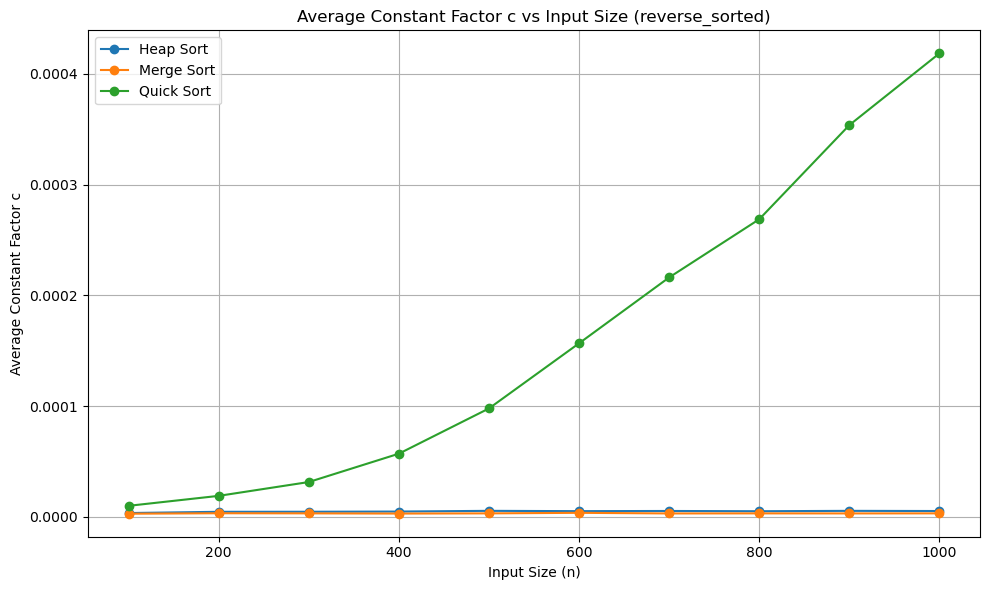

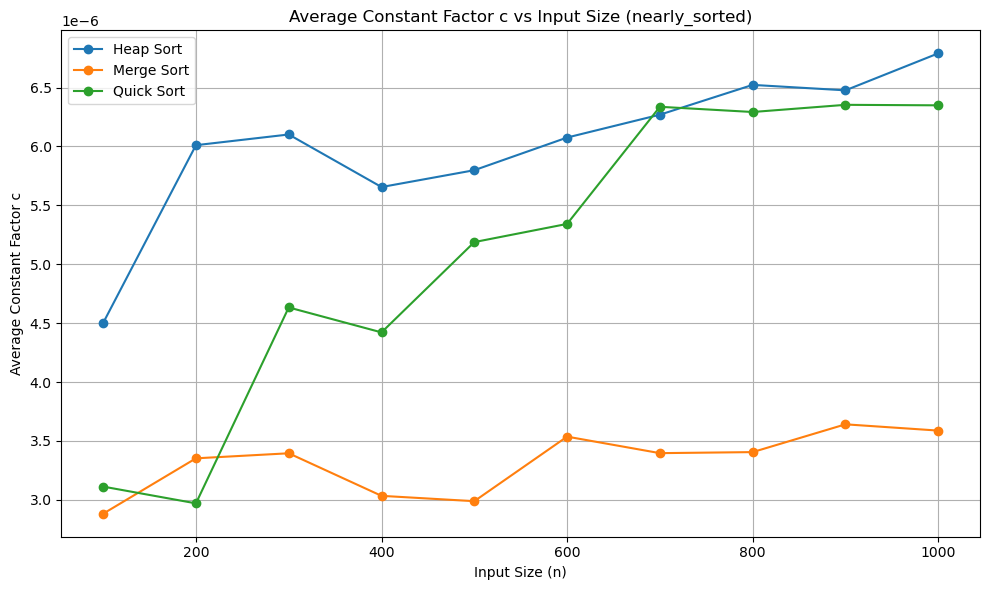

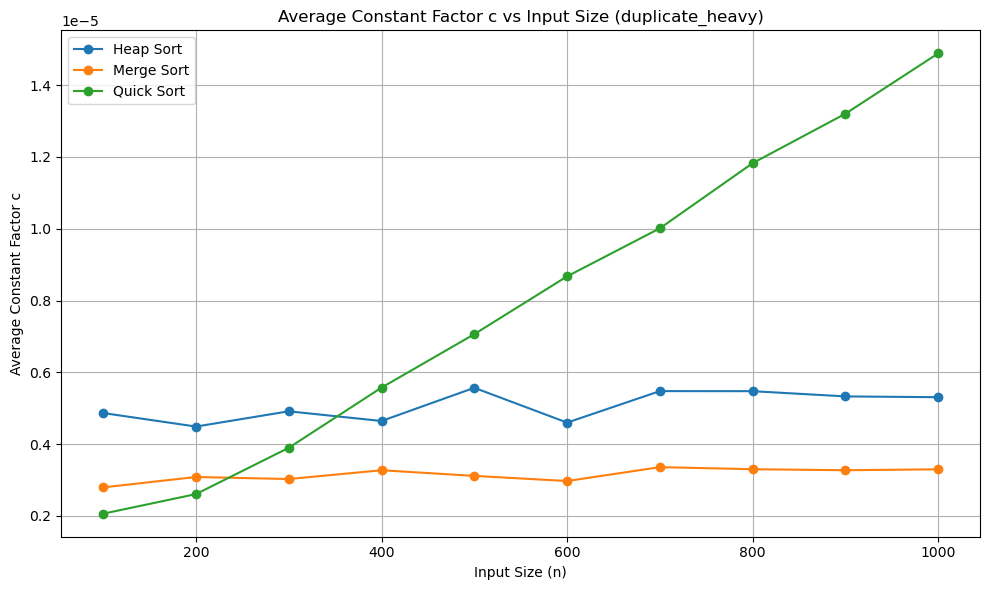

In [ ]:
##Generate all graphs
plot_metric("Avg_Time", "Average Time", "avg_time_vs_n")
plot_metric("Avg_Comparisons", "Average Comparisons", "comparisons_vs_n")
plot_metric("Avg_Swaps_Data_Movements", "Average Swaps/Data Movements", "swaps_vs_n")
plot_metric("Avg_Recursive_Calls", "Average Recursive Calls", "recursive_calls_vs_n")
plot_metric("Avg_Max_Recursion_Depth", "Average Maximum Recursion Depth", "max_recursion_depth_vs_n")
plot_metric("Avg_Peak_Memory_Bytes", "Average Peak Memory Usage Bytes", "memory_usage_vs_n")
plot_metric("Avg_Constant_c", "Average Constant Factor c", "constant_factor_vs_n")

In [ ]:
##Display final clean table
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

display(summary_df)

,Input Type,n,Algorithm,Avg_Time,Min_Time,Max_Time,Avg_Comparisons,Avg_Swaps_Data_Movements,Avg_Recursive_Calls,Avg_Max_Recursion_Depth,Avg_Peak_Memory_Bytes,Avg_Constant_c
0,duplicate_heavy,100,Heap Sort,0.003232,0.001755,0.007166,993.1,537.6,587.6,7.0,16399.2,0.000005
1,duplicate_heavy,100,Merge Sort,0.001855,0.001594,0.002547,535.3,672.0,199.0,8.0,4152.0,0.000003
2,duplicate_heavy,100,Quick Sort,0.001368,0.000879,0.002662,861.4,166.3,181.0,19.8,1544.0,0.000002
3,duplicate_heavy,200,Heap Sort,0.006860,0.005161,0.009770,2345.4,1252.1,1352.1,8.0,17229.7,0.000004
4,duplicate_heavy,200,Merge Sort,0.004712,0.003844,0.006165,1251.3,1544.0,399.0,9.0,6736.0,0.000003
5,duplicate_heavy,200,Quick Sort,0.003983,0.003180,0.004597,2754.6,392.1,381.0,31.5,2403.2,0.000003
6,duplicate_heavy,300,Heap Sort,0.012128,0.009846,0.017741,3848.9,2043.3,2193.3,9.0,17844.0,0.000005
7,duplicate_heavy,300,Merge Sort,0.007468,0.006737,0.009097,2047.3,2488.0,599.0,10.0,9400.8,0.000003
8,duplicate_heavy,300,Quick Sort,0.009616,0.007102,0.014130,5632.8,602.5,581.0,42.9,5182.4,0.000004
9,duplicate_heavy,400,Heap Sort,0.016051,0.014447,0.017602,5403.3,2853.5,3053.5,9.0,4009.5,0.000005


In [15]:
# Overall best algorithm by average time
fastest = summary_df.groupby("Algorithm")["Avg_Time"].mean().sort_values()
print("Overall speed ranking:")
print(fastest)

print("\nOverall comparison count:")
print(summary_df.groupby("Algorithm")["Avg_Comparisons"].mean().sort_values())

print("\nOverall swaps/data movements:")
print(summary_df.groupby("Algorithm")["Avg_Swaps_Data_Movements"].mean().sort_values())

print("\nOverall memory usage:")
print(summary_df.groupby("Algorithm")["Avg_Peak_Memory_Bytes"].mean().sort_values())

print("\nOverall constant factor:")
print(summary_df.groupby("Algorithm")["Avg_Constant_c"].mean().sort_values())

Overall speed ranking:
Algorithm
Merge Sort    0.018268
Heap Sort     0.031077
Quick Sort    0.508347
Name: Avg_Time, dtype: float64

Overall comparison count:
Algorithm
Merge Sort     3586.994
Heap Sort      8527.946
Quick Sort    84730.574
Name: Avg_Comparisons, dtype: float64

Overall swaps/data movements:
Algorithm
Quick Sort    1080.730
Heap Sort     4616.788
Merge Sort    5156.000
Name: Avg_Swaps_Data_Movements, dtype: float64

Overall memory usage:
Algorithm
Heap Sort      9856.994
Merge Sort    17354.318
Quick Sort    34742.074
Name: Avg_Peak_Memory_Bytes, dtype: float64

Overall constant factor:
Algorithm
Merge Sort    0.000003
Heap Sort     0.000006
Quick Sort    0.000070
Name: Avg_Constant_c, dtype: float64


In [16]:
##input-type analysis
for input_type in input_types:
    print("\n" + "="*60)
    print("Input Type:", input_type)
    print("="*60)

    data = summary_df[summary_df["Input Type"] == input_type]

    print("\nFastest algorithm:")
    print(data.groupby("Algorithm")["Avg_Time"].mean().sort_values())

    print("\nLowest comparisons:")
    print(data.groupby("Algorithm")["Avg_Comparisons"].mean().sort_values())

    print("\nLowest constant factor:")
    print(data.groupby("Algorithm")["Avg_Constant_c"].mean().sort_values())


Input Type: random

Fastest algorithm:
Algorithm
Quick Sort    0.015777
Merge Sort    0.017547
Heap Sort     0.029703
Name: Avg_Time, dtype: float64

Lowest comparisons:
Algorithm
Merge Sort    4440.13
Quick Sort    5559.26
Heap Sort     8578.27
Name: Avg_Comparisons, dtype: float64

Lowest constant factor:
Algorithm
Quick Sort    0.000003
Merge Sort    0.000003
Heap Sort     0.000006
Name: Avg_Constant_c, dtype: float64

Input Type: sorted

Fastest algorithm:
Algorithm
Merge Sort    0.023873
Heap Sort     0.040627
Quick Sort    1.201370
Name: Avg_Time, dtype: float64

Lowest comparisons:
Algorithm
Merge Sort      2490.4
Heap Sort       8983.8
Quick Sort    192225.0
Name: Avg_Comparisons, dtype: float64

Lowest constant factor:
Algorithm
Merge Sort    0.000004
Heap Sort     0.000007
Quick Sort    0.000169
Name: Avg_Constant_c, dtype: float64

Input Type: reverse_sorted

Fastest algorithm:
Algorithm
Merge Sort    0.015851
Heap Sort     0.026040
Quick Sort    1.241342
Name: Avg_Time, dt